In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\lenovo\OneDrive\Desktop\data science\sample data\WineQT.csv")

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [5]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


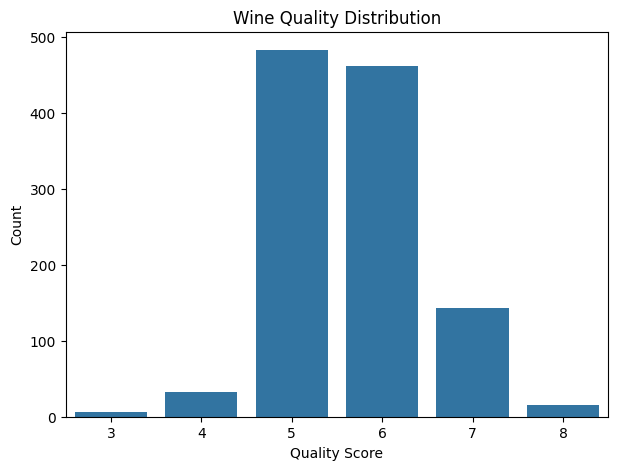

In [12]:
plt.figure(figsize=(7,5))
sns.countplot(x="quality", data=df)
plt.title("Wine Quality Distribution")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.show()

In [13]:

df["quality"].value_counts().sort_index()

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

# EDA 

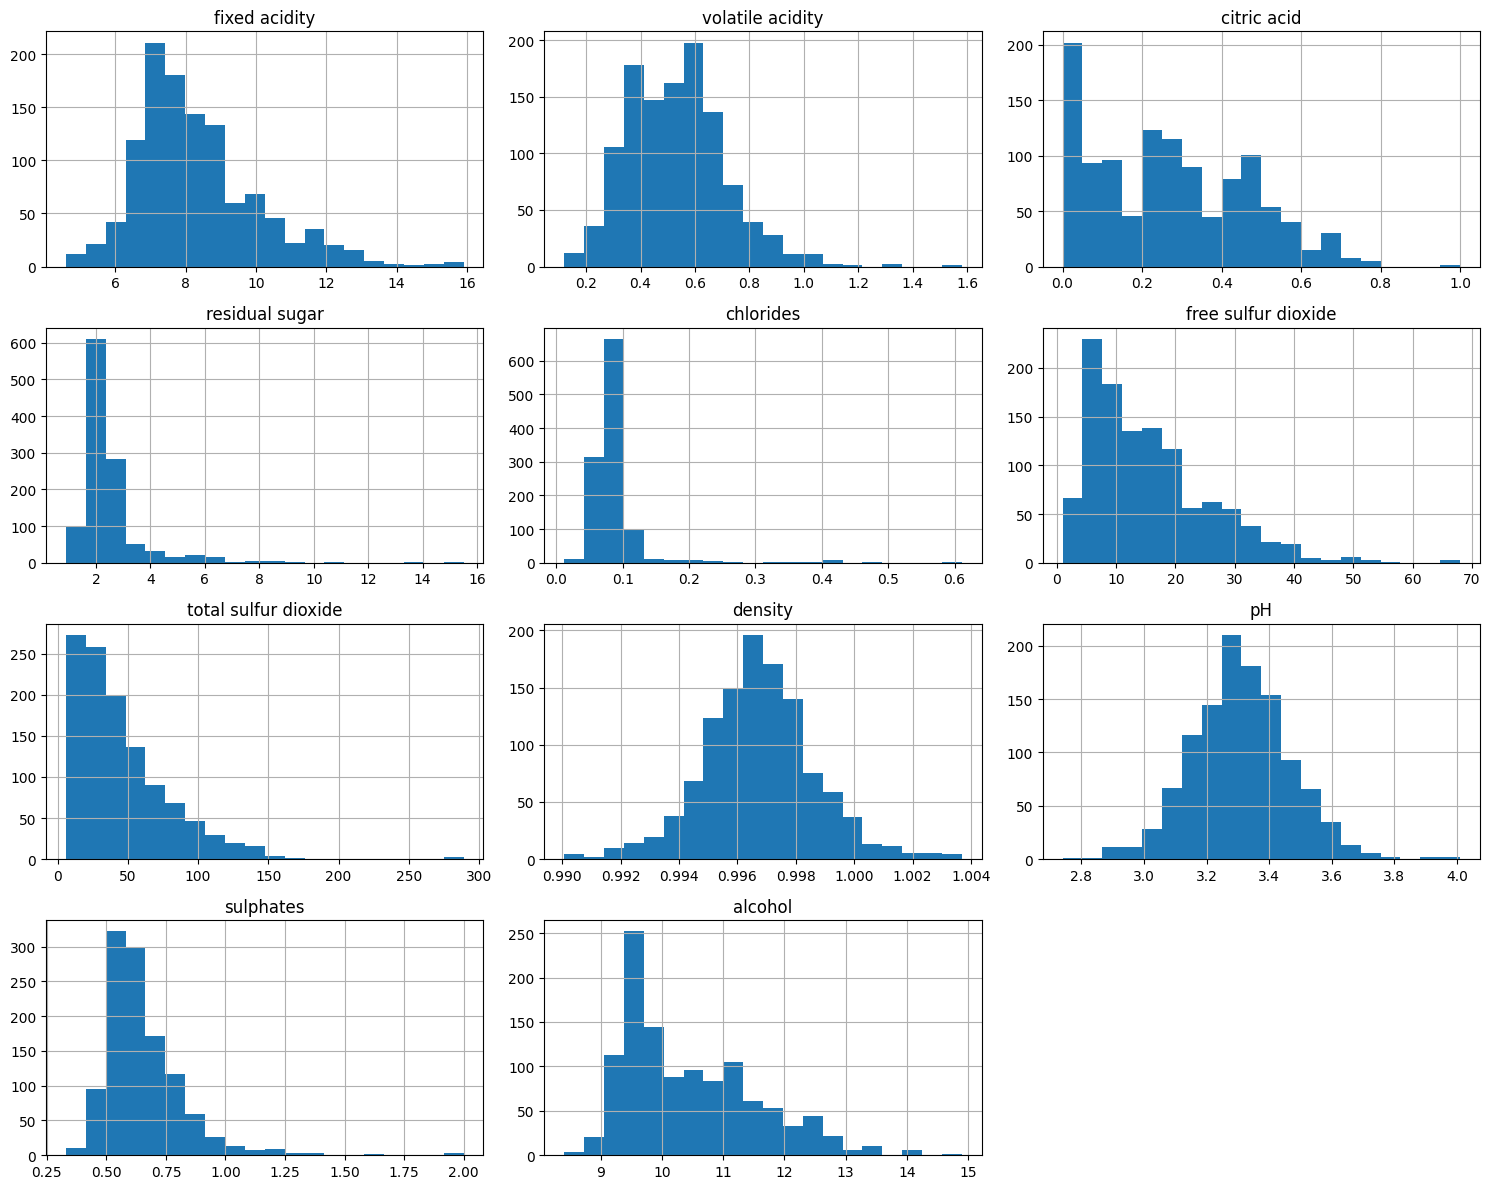

In [17]:
features = df.drop(columns=["quality","Id"]).columns
df[features].hist(figsize=(15,12), bins=20)
plt.tight_layout()
plt.show() 

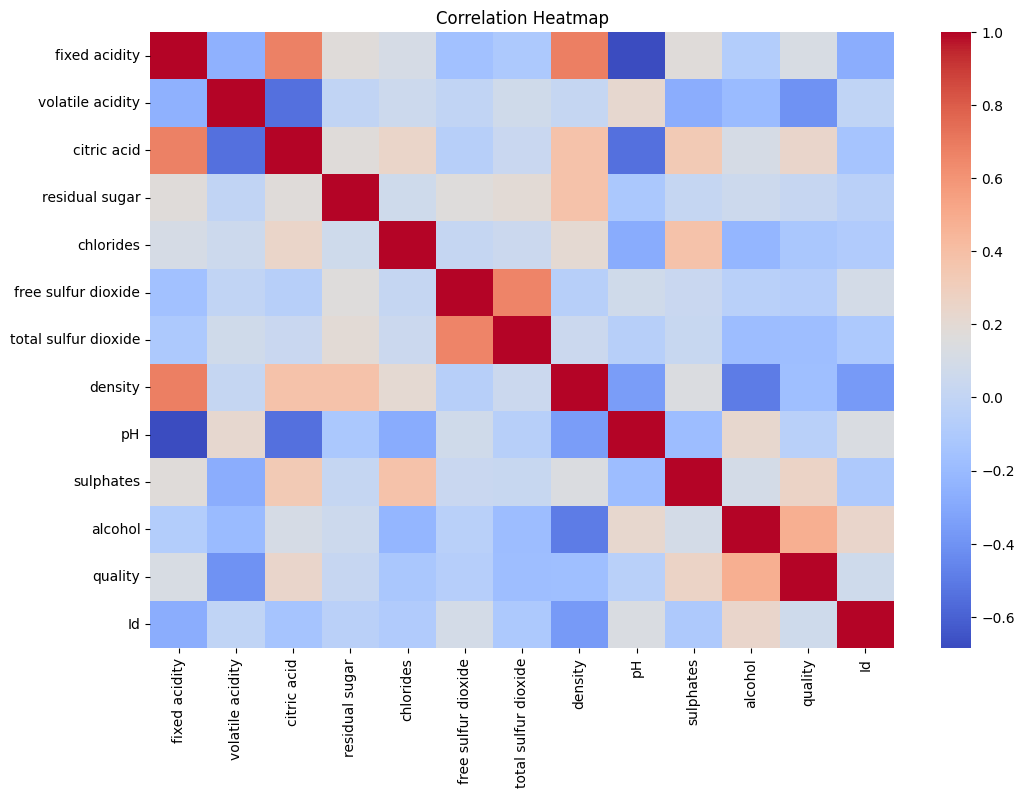

In [24]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show() 

The dataset contains different numbers of samples for each quality score.
Some quality classes have many samples, while others have relatively few.
This imbalance can reduce prediction accuracy for minority classes.
Stratified train-test splitting is used to maintain the original class distribution.

# feature engineering

In [26]:
df["quality_label"] = np.where(df["quality"] >= 6, 1, 0)
df["quality_label"].value_counts() 

quality_label
1    621
0    522
Name: count, dtype: int64

The original quality scores range from multiple classes.
To simplify the classification problem, the quality scores are converted into two classes:
• Good Wine (quality ≥ 6)
• Bad Wine (quality < 6)

# split dataset

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X = df.drop(["quality","quality_label","Id"], axis=1)

In [29]:
y = df["quality_label"]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# train

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
scaler = StandardScaler()

In [43]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
 # random forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test) 

In [53]:
# SGD 
from sklearn.linear_model import SGDClassifier
sgd = SGDClassifier(random_state=42)
sgd.fit(X_train_scaled, y_train)
sgd_pred = sgd.predict(X_test_scaled) 

In [60]:
# support vector 
from sklearn.svm import SVC
svc = SVC(random_state=42)
svc.fit(X_train_scaled, y_train)
svc_pred = svc.predict(X_test_scaled) 

In [68]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# evaluate 

Random Forest Accuracy
0.8034934497816594
              precision    recall  f1-score   support

           0       0.81      0.75      0.78       105
           1       0.80      0.85      0.82       124

    accuracy                           0.80       229
   macro avg       0.80      0.80      0.80       229
weighted avg       0.80      0.80      0.80       229



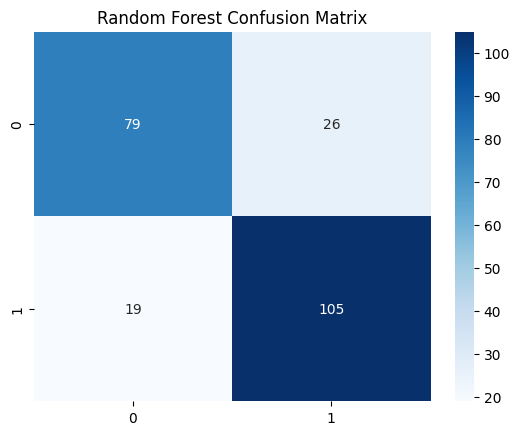

In [76]:
print("Random Forest Accuracy")
print(accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

sns.heatmap(confusion_matrix(y_test, rf_pred),
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.show() 

SGD Accuracy
0.62882096069869
              precision    recall  f1-score   support

           0       0.67      0.38      0.48       105
           1       0.62      0.84      0.71       124

    accuracy                           0.63       229
   macro avg       0.64      0.61      0.60       229
weighted avg       0.64      0.63      0.61       229



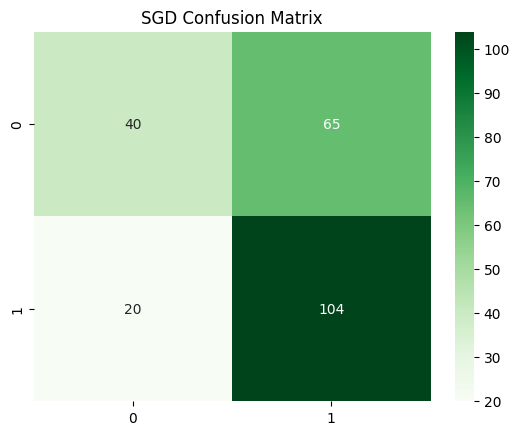

In [83]:
print("SGD Accuracy")
print(accuracy_score(y_test, sgd_pred))

print(classification_report(y_test, sgd_pred))

sns.heatmap(confusion_matrix(y_test, sgd_pred),
            annot=True,
            fmt="d",
            cmap="Greens")

plt.title("SGD Confusion Matrix")
plt.show()

SVC Accuracy
0.7860262008733624
              precision    recall  f1-score   support

           0       0.77      0.75      0.76       105
           1       0.80      0.81      0.80       124

    accuracy                           0.79       229
   macro avg       0.78      0.78      0.78       229
weighted avg       0.79      0.79      0.79       229



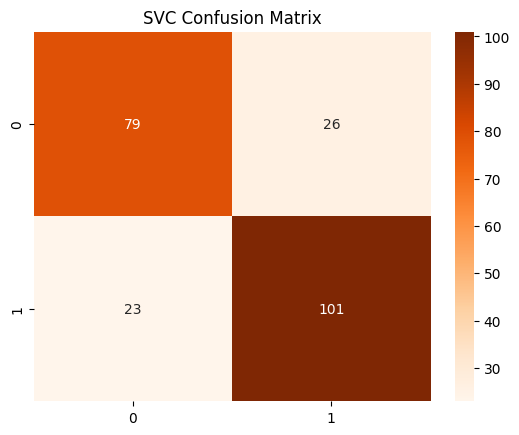

In [91]:
print("SVC Accuracy")
print(accuracy_score(y_test, svc_pred))

print(classification_report(y_test, svc_pred))

sns.heatmap(confusion_matrix(y_test, svc_pred),
            annot=True,
            fmt="d",
            cmap="Oranges")

plt.title("SVC Confusion Matrix")
plt.show()

# feature importance for random forest

In [97]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
10,alcohol,0.197984
9,sulphates,0.133975
6,total sulfur dioxide,0.103693
1,volatile acidity,0.099980
7,density,0.083448
4,chlorides,0.070481
0,fixed acidity,0.068979
8,pH,0.067013
5,free sulfur dioxide,0.060420
2,citric acid,0.058711


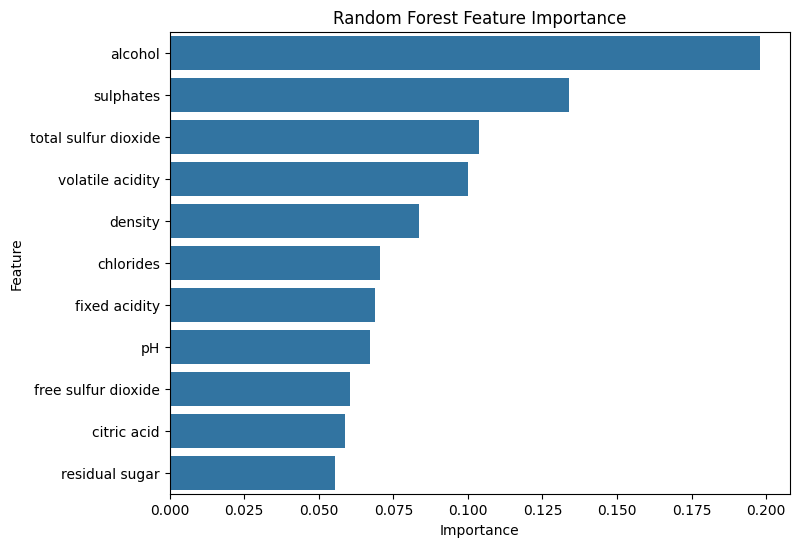

In [104]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

# comparison table

In [110]:
comparison = pd.DataFrame({

    "Model":[
        "Random Forest",
        "SGD",
        "SVC"
    ],

    "Accuracy":[
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, sgd_pred),
        accuracy_score(y_test, svc_pred)
    ]

})

comparison

,Model,Accuracy
0,Random Forest,0.803493
1,SGD,0.628821
2,SVC,0.786026


# conclusion


In [111]:
# Developed wine quality prediction models using Random Forest, SGD, and SVC.
# Evaluated each model using Accuracy, Classification Report, and Confusion Matrix.
# Used Random Forest feature importance to identify the most influential chemical properties.
# Compared the performance of all three models.
# Selected the model with the best accuracy and balanced performance as the most suitable for deployment.